In [130]:
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed
from IPython.display import display, clear_output
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [121]:
dataset = pd.read_csv('datasets/Airline_Customers.csv')
data = dataset.sample(n=10_000, random_state=37).reset_index(drop=True)

value = data.fillna({'Arrival Delay in Minutes':0}, inplace=True)
data['satisfaction'] = data['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Customer Type'] = data['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
data['Type of Travel'] = data['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
data['Class'] = (data['Class'] == 'Business').astype(int)

# data.head()

In [122]:
# data.info()

In [123]:
# data.describe()

In [124]:
# data.isna().sum()

In [125]:
storage = {}
scaler = StandardScaler()

def get_dendro(method='ward', p=4, exclude=[]):
    dropped_df = data.drop(columns=exclude)
    X = scaler.fit_transform(dropped_df)
    linkage_matrix = linkage(X, method=method)
    storage['linkage_matrix'] = linkage_matrix
    storage['df'] = dropped_df
    dendro = dendrogram(
        linkage_matrix,
        truncate_mode='level',
        p=p
    )
    return dendro

def interactive_dendro():
    method_selector = widgets.Dropdown(
        options=['single', 'complete', 'average', 'ward', 'weighted', 'centroid', 'median'],
        value='ward',
        description='Linkage:',
        # style={'description_width': 'initial'},
    )
    p_slider = widgets.IntSlider(
        value=4,
        min=1,
        max=5,
        step=1,
        description='p value:',
        continuous_update=False,
        orientation='horizontal',
        readout_format='d'
    )

    columns_selector = widgets.SelectMultiple(
        options=data.columns.tolist(),
        value=['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
           'Class', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
           'Inflight wifi service', 'Inflight entertainment', 'Online support',
           'Ease of Online booking', 'On-board service', 'Leg room service',
           'Baggage handling', 'Cleanliness', 'Online boarding',
           'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
        description='Exclude:',
        continuous_update=False,
        rows=len(data.columns),
    )

    plot_output = widgets.Output()
    def on_change(method='ward', p=4, exclude=['']):
        with plot_output:
            plot_output.clear_output()
            plt.figure(figsize=(12,8))
            dendro = get_dendro(method=method, p=p, exclude=list(exclude))
            plt.title(f'Airline Customers Clustering: {len(df)}')
            plt.show()

    widgets.interactive_output(on_change, {'method': method_selector, 'p': p_slider, 'exclude': columns_selector})
    controls = widgets.HBox([method_selector, p_slider])
    body = widgets.HBox([columns_selector, plot_output])
    ui = widgets.VBox([controls, body])
    return ui


output = widgets.Output()

button_start = widgets.Button(
    description='Start',
)

def on_button_start(b):
    with output:
        output.clear_output()
        ui = interactive_dendro()
        display(ui)
        
button_start.on_click(on_button_start)
display(button_start, output)

Button(description='Start', style=ButtonStyle())

Output()

In [126]:
df = storage['df']
# df = data.copy()
df.head()

,Flight Distance,Seat comfort,Checkin service
0,2284,1,4
1,1662,3,4
2,2782,2,4
3,983,4,1
4,2193,4,4


In [127]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

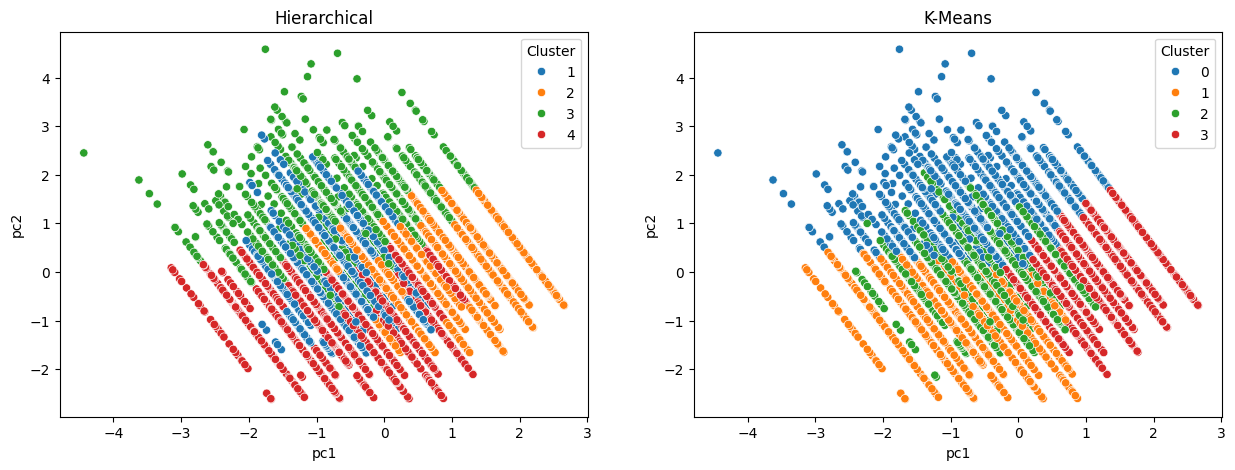

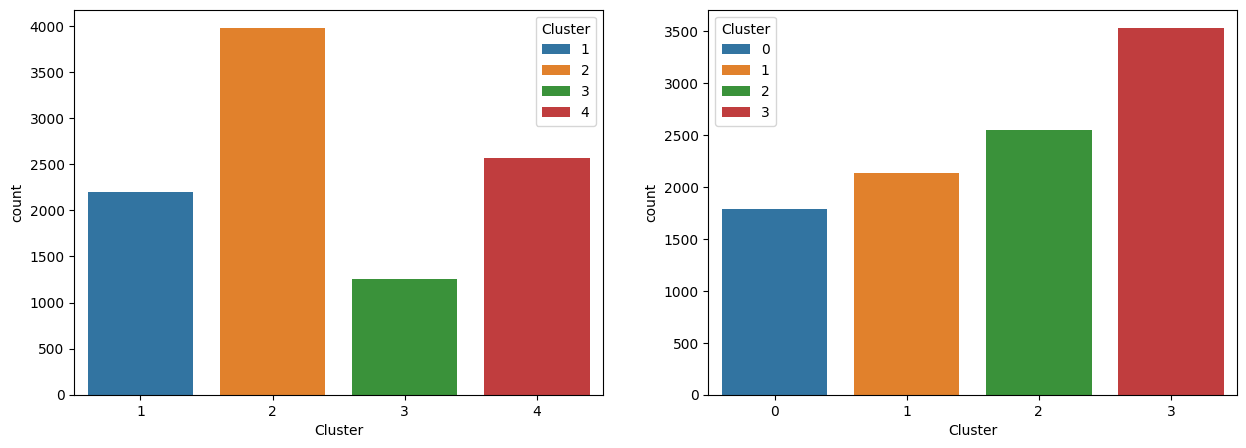

Hierarchy summary
         Flight Distance  Seat comfort  Checkin service
Cluster                                                
1            1877.950432      1.190541         3.816735
2            1630.503395      3.454363         4.079205
3            3772.648928      3.256553         3.192216
4            1773.000390      3.123977         1.823392



Kmeans summary
         Flight Distance  Seat comfort  Checkin service
Cluster                                                
0            3516.563901      2.934417         3.561659
1            1819.635597      2.732084         1.459485
2            1678.073276      1.365596         3.883229
3            1550.218475      3.943327         3.947861


In [136]:
num_clusters = 4

linkage_matrix = storage['linkage_matrix']
h_clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

hierarchy_df = pd.DataFrame({
    'pc1': pca_result[:,0],
    'pc2': pca_result[:, 1],
    'Cluster': h_clusters
})

kmeans = KMeans(n_clusters=num_clusters, random_state=37)
kmeans_clusters = kmeans.fit_predict(scaled_features)

kmeans_df = pd.DataFrame({
    'pc1': pca_result[:, 0],
    'pc2': pca_result[:, 1],
    'Cluster': kmeans_clusters,
})


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=hierarchy_df, x='pc1', y='pc2', hue='Cluster', palette='tab10', ax=axes[0])
axes[0].set_title('Hierarchical')

sns.scatterplot(data=kmeans_df, x='pc1', y='pc2', hue='Cluster', palette='tab10', ax=axes[1])
axes[1].set_title('K-Means')
plt.show()


def annotate(axis):
    for p in axis.patches:
        height = p.get_height()                
        ax.annotate(
            f'{height}',                       
            (p.get_x() + p.get_width() / 2., height),  
            ha='center',                      
            va='bottom',                       
            fontsize=10,                        
            color='black'                       
        )

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=hierarchy_df, x='Cluster', hue='Cluster', palette='tab10', ax=axes[0])
annotate(axes[0])

sns.countplot(data=kmeans_df, x='Cluster', hue='Cluster', palette='tab10', ax=axes[1])
annotate(axes[1])

plt.show()


h_data_copy = data.copy()
h_data_copy['Cluster'] = h_clusters
kmeans_data_copy = data.copy()
kmeans_data_copy['Cluster'] = kmeans_clusters

h_cluster_summary = h_data_copy.groupby('Cluster')[['Flight Distance', 'Seat comfort', 'Checkin service']].mean()
print('Hierarchy summary')
print(h_cluster_summary)
print('\n\n')

kmeans_cluster_summary = kmeans_data_copy.groupby('Cluster')[['Flight Distance', 'Seat comfort', 'Checkin service']].mean()
print('Kmeans summary')
print(kmeans_cluster_summary)

[0.21914635080932895, 0.22332128073596763, 0.2177632413471224, 0.20119513685843854, 0.18666967197175263, 0.18541998802929588]


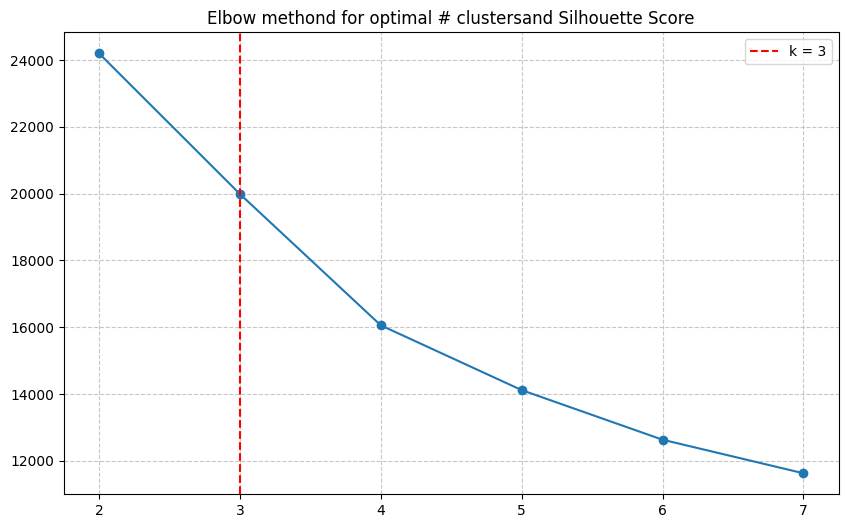

In [137]:
inertia = []
silhouette_scores = []
k_range = range(2, 8)

# within-cluster sum of squares
def wcss(X, labels):
    total = 0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        total += ((cluster_points - centroid) ** 2).sum()
    return total


for k in k_range:
    cluster_labels = fcluster(linkage_matrix, k, criterion='maxclust')
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)
    inertia.append(wcss(scaled_features, cluster_labels))

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')


print(silhouette_scores)

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.axvline(x = best_k_silhouette, color='red', linestyle='--', 
            label=f'k = {best_k_silhouette}')

plt.title('Elbow methond for optimal # clustersand Silhouette Score')
plt.grid(True, linestyle='--', alpha=.7)
plt.legend()
plt.show()